# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


In [286]:
# =========================
# Part 1: NLP Starter Code
# =========================

# TODO: Import the libraries you need for:
# - data handling
import pandas as pd
import numpy as np

from warnings import filterwarnings
filterwarnings('ignore')

# - plotting
import matplotlib.pyplot as plt
import seaborn as sns

# - text preprocessing
import nltk
import re
import string
from collections import Counter

# - tokenization / stopwords / lemmatization
from nltk.tokenize import word_tokenize, sent_tokenize, RegexpTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

# - counting words and bigrams
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.util import ngrams

# Example:
# import pandas as pd


# TODO: Download any required NLTK resources.
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')


# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
df = pd.read_csv('amazon_reviews_lab.csv')


[nltk_data] Downloading package punkt to
[nltk_data]     c:\Users\Admin\anaconda3\envs\ai-
[nltk_data]     environment\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     c:\Users\Admin\anaconda3\envs\ai-
[nltk_data]     environment\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     c:\Users\Admin\anaconda3\envs\ai-
[nltk_data]     environment\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     c:\Users\Admin\anaconda3\envs\ai-
[nltk_data]     environment\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     c:\Users\Admin\anaconda3\envs\ai-
[nltk_data]     environment\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nlt

In [288]:
# TODO: Explore the dataset.
# Suggested checks:
# - shape
print("\nThe shape of the dataset is:", df.shape)

# - value counts for the rating column
print("\n**Value counts for the rating column**")
print(df['rating'].value_counts())

print(df[['review_text', 'rating']].head())


The shape of the dataset is: (997, 9)

**Value counts for the rating column**
rating
5    580
4    188
3     94
1     87
2     48
Name: count, dtype: int64
                                         review_text  rating
0  This film is definitely not for anyone who is ...       2
1  This movie was playing at Radio City Music Hal...       5
2  I would love to buy this movie as I have been ...       1
3  The advertisment for this DVD on Amazon was in...       1
4  I bought some of these to try with a light usi...       5


sentiment_label
positive    637
neutral     321
negative     39
Name: count, dtype: int64

**First few rows of the dataset with sentiment labels**
                                         review_text  rating sentiment_label
0  This film is definitely not for anyone who is ...       2        positive
1  This movie was playing at Radio City Music Hal...       5        positive
2  I would love to buy this movie as I have been ...       1        positive
3  The advertisment for this DVD on Amazon was in...       1         neutral
4  I bought some of these to try with a light usi...       5         neutral


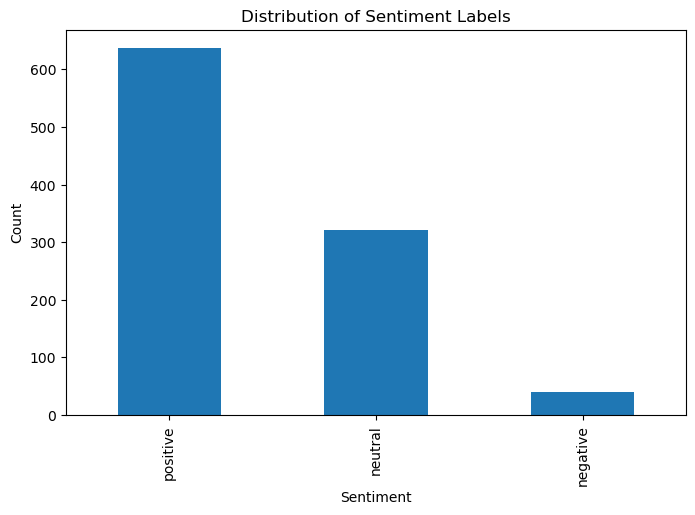

In [295]:
# Add a sentiment label based on sentiment analysis

df['sentiment_label'] = df['review_text'].apply(lambda x: 'negative' 
                                                if sia.polarity_scores(x)['compound'] <= -0.6 
                                                else 'positive' 
                                                if sia.polarity_scores(x)['compound'] >= 0.6 
                                                else 'neutral')

print(df['sentiment_label'].value_counts())

print("\n**First few rows of the dataset with sentiment labels**")
print(df[['review_text', 'rating', 'sentiment_label']].head())

#Visualize the distribution of sentiment labels
plt.figure(figsize=(8, 5))
df['sentiment_label'].value_counts().plot(kind='bar')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [302]:


# TODO: Create preprocessing tools such as:
# - stop_words
stop_words = set(stopwords.words('english'))

# - lemmatizer
lemmatizer = WordNetLemmatizer()

# TODO: Write a function called preprocess_text(text) that:

def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Tokenize the text
    tokens = word_tokenize(text)
    # 5. Keep alphabetic tokens only
    tokens = [token for token in tokens if token.isalpha()]
    # 6. Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]
    # 7. Lemmatize the remaining tokens
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # 8. Return the cleaned tokens
    return tokens 

# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.
df['processed_tokens'] = df['review_text'].apply(preprocess_text)

print("\n**First few rows of the dataset with processed tokens**")
print(df['processed_tokens'].head())



**First few rows of the dataset with processed tokens**
0    [film, definitely, anyone, especially, fond, i...
1    [movie, playing, radio, city, music, hall, bac...
2    [would, love, buy, movie, hannibal, missouri, ...
3    [advertisment, dvd, amazon, incorrect, ad, sta...
4    [bought, try, light, using, work, advertised, ...
Name: processed_tokens, dtype: object


In [308]:
# TODO: Combine all tokens into one list so you can compute word frequencies.
all_tokens = [token for tokens in df['processed_tokens'] for token in tokens]

print(all_tokens[:15])  # Display the first few tokens

['film', 'definitely', 'anyone', 'especially', 'fond', 'independent', 'delightfully', 'manipulative', 'clever', 'boy', 'brain', 'child', 'samuel', 'clemens', 'classicas']



**Most common words**
[('nook', 1509), ('book', 913), ('one', 569), ('kindle', 561), ('screen', 496), ('like', 459), ('read', 454), ('work', 446), ('get', 424), ('great', 422)]

**Most common bigrams**
[(('barnes', 'noble'), 152), (('nook', 'color'), 127), (('battery', 'life'), 87), (('touch', 'screen'), 81), (('sd', 'card'), 80), (('nook', 'hd'), 74), (('work', 'great'), 63), (('nook', 'tablet'), 63), (('work', 'well'), 57), (('read', 'book'), 55)]


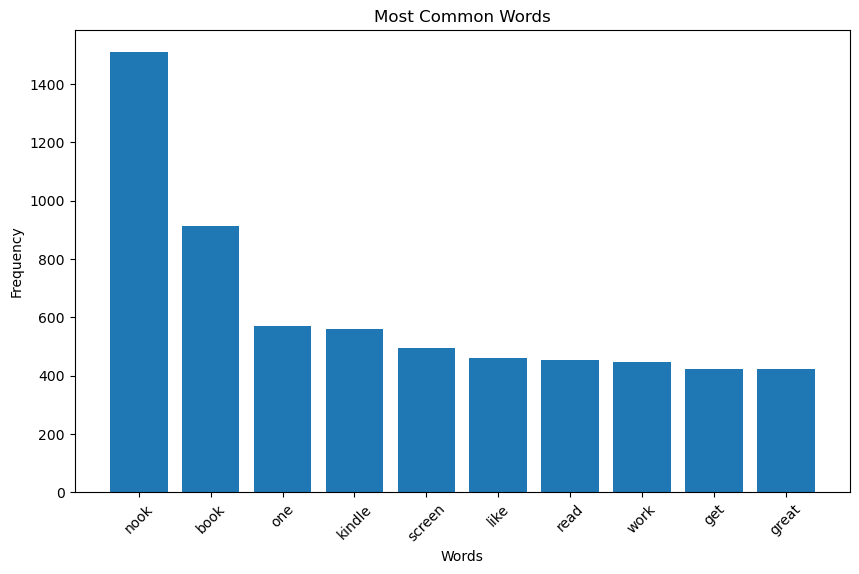

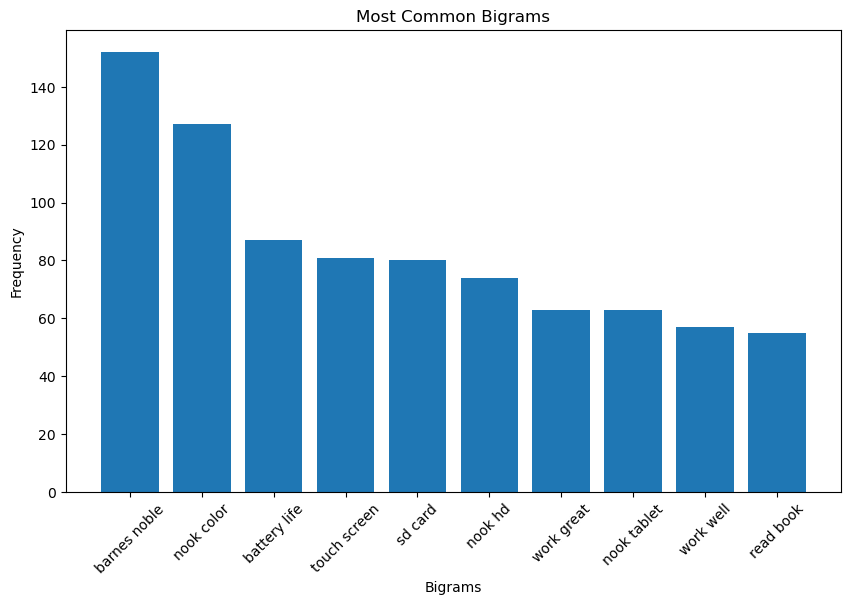

In [319]:
# TODO: Use Counter to identify the most common words.
word_freq = Counter(all_tokens)
print("\n**Most common words**")
print(word_freq.most_common(10))

# TODO: Generate bigrams from the token list and identify the most common bigrams.
bigrams = list(ngrams(all_tokens, 2))
bigram_freq = Counter(bigrams)
print("\n**Most common bigrams**")
print(bigram_freq.most_common(10))

# TODO: Create at least one visualization of the most common words.

# Visualize the most common words
plt.figure(figsize=(10, 6))
word_freq.most_common(10)
plt.bar([word for word, _ in word_freq.most_common(10)], [freq for _, freq in word_freq.most_common(10)])
plt.title('Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Visualize the most common bigrams.
plt.figure(figsize=(10, 6))
bigram_freq.most_common(10)
plt.bar([' '.join(bigram) for bigram, _ in bigram_freq.most_common(10)], [freq for _, freq in bigram_freq.most_common(10)])
plt.title('Most Common Bigrams')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Now classify reviews and sentiment labels more accurately and predict better star ratings based on the pre-processed text content.

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Join pretokens back to text
df['preprocessed_text'] = df['processed_tokens'].apply(lambda x: ' '.join(x))

# Calculate detailed sentiment scores
df['sentiment_scores'] = df['preprocessed_text'].apply(lambda x: sia.polarity_scores(x))

# Extract individual sentiment components
df['sentiment_neg'] = df['sentiment_scores'].apply(lambda x: x['neg'])
df['sentiment_neu'] = df['sentiment_scores'].apply(lambda x: x['neu'])
df['sentiment_pos'] = df['sentiment_scores'].apply(lambda x: x['pos'])
df['sentiment_compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])

# Classify sentiment based on compound score
df['sentiment'] = df['sentiment_compound'].apply(
   lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

# Calculate agreement between sentiment and rating
df['predicted_rating'] = df['sentiment_compound'].apply(
   lambda x: 5 if x > 0.9 else (
             4 if x > 0.6 else (
             3 if x > 0.2 else (
             2 if x > 0.0 else 1)))
)

# Display the first few reviews with their initial ratings and predicted ratings after preprocessing
print("\nSample reviews:")
for i in range(5):
   print(f"\nInitial Rating: {df['rating'][i]} | New Rating: {df['predicted_rating'][i]}/5")
   print(f"Review: {df['review_text'][i][:170]}...")

agreement = (df['rating'] == df['predicted_rating']).mean() * 100
print(f"\nAgreement between initial rating and sentiment-predicted rating: {agreement:.1f}%")



Sample reviews:

Initial Rating: 2 | New Rating: 5/5
Review: This film is definitely not for anyone who is especially fond of the independent, delightfully manipulative and clever boy who was the brain child of Samuel Clemens's cla...

Initial Rating: 5 | New Rating: 4/5
Review: This movie was playing at Radio City Music Hall back in the days of the movie/stage show formt. It was also presented in 70mm on that huge Radio City screen. I remember h...

Initial Rating: 1 | New Rating: 4/5
Review: I would love to buy this movie as I have been to Hannibal Missouri and been to all the Mark Twain atractions.To buy this movie would be a real treat but if it's Pan&Scan ...

Initial Rating: 1 | New Rating: 1/5
Review: The advertisment for this DVD on Amazon was incorrect. The ad stated that the DVD was in Wide Screen Anamorphic format. The DVD was not in this format, it was standard Pa...

Initial Rating: 5 | New Rating: 1/5
Review: I bought some of these to try with a light using 123 A's. They

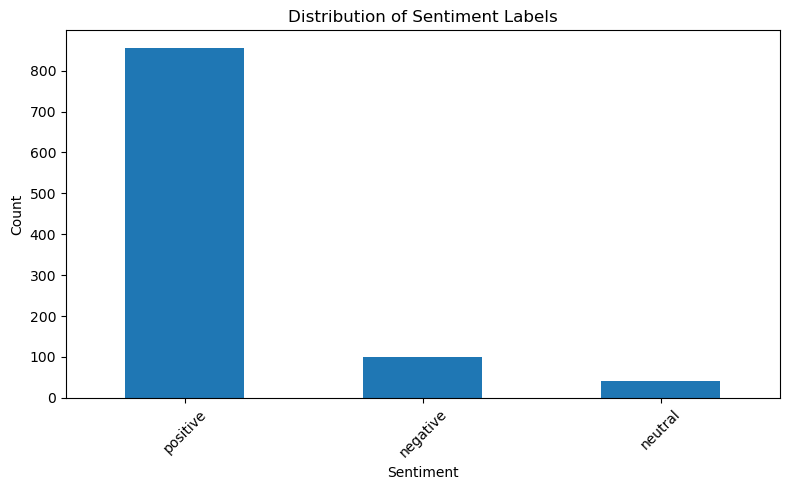

In [341]:
# Visualize the distribution of sentiment labels
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Reflection

**Customer sentiment or product experience with reference to most common words and most common bigrams**


The two graphs suggest that customers are mainly discussing e-readers/books and their practical experience using the devices, with a mixture of positive feedback and product-specific concerns.

In the most common words, terms such as “nook,” “book,” “kindle,” “screen,” and “read” show that reviews are strongly focused on the reading experience and comparison of e-reader products. The appearance of positive words such as “like” and “great” suggests that at least some customers are expressing satisfaction. However, word frequency alone cannot tell us whether overall sentiment is positive or negative—for example, “screen” could appear in either “great screen” or “screen stopped working.”

The bigrams provide more useful context. Phrases such as “work great” and “work well” indicate positive customer experiences, suggesting that many customers are satisfied with product performance. “battery life” and “touch screen” highlight specific features customers care about, while “SD card” suggests that storage or expandable memory is also an important part of the experience. Bigrams such as “nook color,” “nook hd,” and “nook tablet” identify particular products being discussed rather than sentiment.

Overall interpretation: The reviews appear to be centered on e-reader functionality and usability, especially reading, screen performance, battery life, and storage. There are clear signs of positive sentiment through phrases such as “work great” and “work well,” but these frequency plots alone are not enough to conclude that customers are generally satisfied. A sentiment analysis or examining words surrounding terms such as “battery life” and “touch screen” would help determine whether customers are praising or complaining about those specific features.

**Reflection on Sentiment Before and After Text Pre-processing**

Before pre-processing, the sentiment distribution was relatively mixed, with approximately 640 positive, 320 neutral, and 40 negative reviews. This suggested that although most customers had positive experiences, a substantial number of reviews were being interpreted as neutral, while very few were considered negative.

After pre-processing, I observed a major change in the sentiment distribution. The number of reviews classified as positive increased to about 850, while negative reviews increased to around 100 and neutral reviews dropped sharply to about 40. This suggests that cleaning the text made the emotional meaning of many reviews clearer to the sentiment analysis method. Removing unnecessary elements such as punctuation, stop words, inconsistent casing, and other noise may have allowed sentiment-bearing words to have a stronger influence on classification.

This comparison helped me understand that text pre-processing can significantly affect sentiment analysis results rather than simply making the text cleaner. Reviews that initially appeared neutral may have contained positive or negative opinions that became easier to detect after cleaning. Overall, the processed data suggests a strongly positive customer experience, which is also consistent with the earlier occurrence of positive phrases such as “work great” and “work well.” However, the large change in class distribution also means I should verify that the pre-processing steps did not remove important contextual information, particularly negation words such as “not,” “no,” or “never,” because removing them could incorrectly turn a negative statement such as “not good” into the apparently positive word “good.”

## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


Earliest timestamp: 2000-05-12 00:00:00
Latest timestamp: 2014-07-17 00:00:00



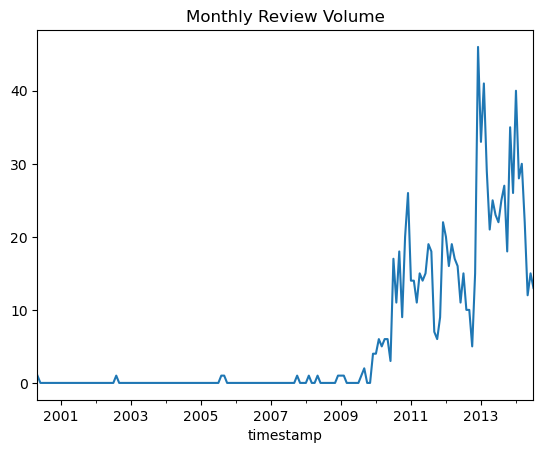

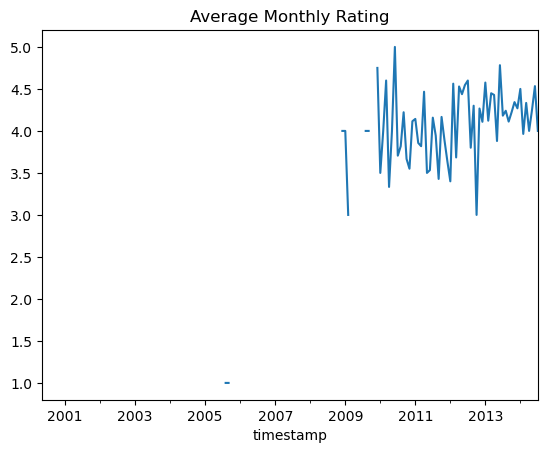

timestamp
2000-05-31   NaN
2000-06-30   NaN
2000-07-31   NaN
2000-08-31   NaN
2000-09-30   NaN
Freq: M, Name: rating, dtype: float64


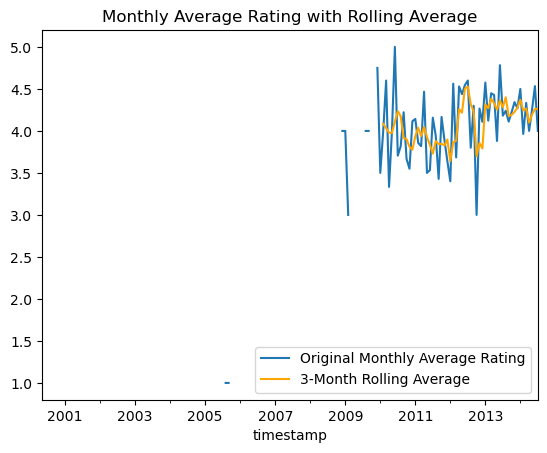

In [252]:
# ==============================
# Part 2: Time Series Starter Code
# ==============================

# TODO: Import the libraries you need.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# TODO: Load the same review dataset.
df = pd.read_csv('amazon_reviews_lab.csv')

# TODO: Convert the timestamp column to datetime format.
df = df.set_index('timestamp')
df.index = pd.to_datetime(df.index)

# TODO: Inspect the date range in the dataset.
# Suggested checks:
# - earliest timestamp
earliest_timestamp = df.index.min()
print("Earliest timestamp:", earliest_timestamp)

# - latest timestamp
latest_timestamp = df.index.max()
print("Latest timestamp:", latest_timestamp)

# TODO: Resample the data by month to calculate:
# 1. monthly review count
# 2. monthly average rating

# Suggested variable names:
monthly_review_count = df['rating'].resample('M').count()
monthly_avg_rating = df['rating'].resample('M').mean()
print()

# TODO: Plot monthly review volume over time.
monthly_review_count.plot(title="Monthly Review Volume")
plt.show()

# TODO: Plot average monthly rating over time.
monthly_avg_rating.plot(title="Average Monthly Rating")
plt.show()


# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.
monthly_avg_rating_rolling = monthly_avg_rating.rolling(window=3).mean()
print(monthly_avg_rating_rolling.head())

# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.
monthly_avg_rating.plot(label='Original Monthly Average Rating', title='Monthly Average Rating with Rolling Average')
monthly_avg_rating_rolling.plot(label='3-Month Rolling Average', color='orange')
plt.legend()
plt.show()

# Reflection prompt:
# What overall trends do you notice in review activity and customer ratings over time?


#### Trends in Review Activity and Customer Ratings

**The Monthly Review Volume** 

The Volume graph for *The Monthly Review*  shows a clear upward trend in customer review activity over time. 

From around 2001 to 2009, review activity was extremely low, with most months recording no reviews and only a few isolated reviews. 

Beginning around 2010, the number of reviews increased noticeably and became more frequent. 

Between 2011 and 2012, monthly review volumes fluctuated but generally remained higher than in earlier years. 

The strongest growth occurred from around 2013 onward, when some months recorded more than 40 reviews, although there were still considerable month-to-month fluctuations. 

Overall, the graph suggests that customer engagement and review activity increased substantially over time, particularly after 2010, while the later period also shows greater variability in monthly review volume.

**The Average Monthly Rating**

The graph shows that customer ratings were generally positive but somewhat variable over time. 

Before 2009, there are very few recorded ratings, including an unusually low rating of about 1.0 around 2005, so this early period should be interpreted cautiously because the low review volume means individual reviews can strongly affect the monthly average. 

From around 2009 onward, ratings mostly fluctuate between 3.5 and 4.6, with occasional peaks reaching 5.0 and a few drops to around 3.0. In the later years, particularly 2013–2014, ratings appear to become slightly more stable and remain mostly above 4.0. 

Overall, the graph suggests that customer satisfaction was generally high and may have improved slightly over time, but the frequent month-to-month fluctuations make it difficult to identify a strong long-term trend from the monthly averages alone. The 3-month rolling average will be especially useful for confirming whether there is a genuine upward or downward trend.

**The Monthly Average Rating with 3-Month Rolling Average** 

This graph shows that customer ratings experience noticeable month-to-month fluctuations, while the rolling average reveals a more stable underlying trend. 

From around 2010 to 2012, the rolling average generally stays between approximately 3.8 and 4.2, suggesting fairly consistent customer satisfaction despite individual monthly ratings ranging from about 3.3 to 5.0. 

Around 2012–2013, the rolling average rises toward 4.4–4.5, indicating an improvement in overall customer satisfaction. From 2013 onward, it remains relatively stable at around 4.2–4.4. 

Overall, the rolling average suggests a slight upward trend in customer ratings over time, followed by stabilization at a relatively high level, while smoothing out the large short-term variations visible in the original monthly

## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


In [253]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import ConfusionMatrixDisplay

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# - train/test splitting
from sklearn.model_selection import train_test_split

# - text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# - model building
import tensorflow as tf
from tensorflow import keras

# - model evaluation
from sklearn.metrics import classification_report, confusion_matrix

# TODO: Load the dataset.
df = pd.read_csv('amazon_reviews_lab.csv')

# Inspect the dataset
print("**The dataset info**")
print(df.info())


**The dataset info**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           997 non-null    object 
 1   rating               997 non-null    int64  
 2   review_text          997 non-null    object 
 3   review_summary       997 non-null    object 
 4   review_time_raw      997 non-null    object 
 5   unix_review_time     997 non-null    float64
 6   timestamp            997 non-null    object 
 7   sentiment_label      997 non-null    object 
 8   review_length_words  997 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 70.2+ KB
None



Rating distribution:
rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64


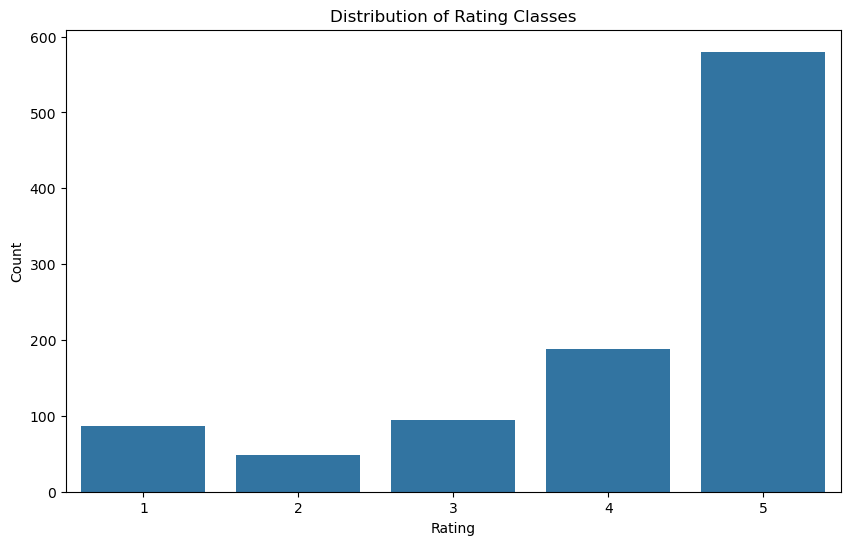

In [254]:
# TODO: Define:
# X as the review text column
X = df['review_text']

# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.
y = df['rating']

print("\nRating distribution:")
print(y.value_counts().sort_index())

# # Visualize the distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(x=y)
plt.title('Distribution of Rating Classes')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [255]:
# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?

vectorizer = TfidfVectorizer(max_features=5000, 
                             stop_words='english', 
                             ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X)

# Print the shape of the TF-IDF matrix to understand the number of samples and features.
print("\nTF-IDF shape:", X_tfidf.shape)



TF-IDF shape: (997, 5000)


In [256]:
#Convert 1–5 ratings to 0–4 for tensor flow compatibility
y = df["rating"] - 1

#Check the classes in the dataset to ensure they are balanced
print("\nOriginal ratings:", sorted(df["rating"].unique()))
print("y values:", sorted(y.unique()))
print("Number of unique classes:", len(np.unique(y)))


Original ratings: [1, 2, 3, 4, 5]
y values: [0, 1, 2, 3, 4]
Number of unique classes: 5


In [257]:
# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Check if the object X_train is a sparse matrix and convert it to a dense array if necessary
# Neural networks usually work more easily with dense arrays.
from scipy.sparse import issparse

print(issparse(X_train))
print(issparse(X_test))

X_train = X_train.toarray()
X_test = X_test.toarray()

print("\nThe type of X_train and X_test after converting to array:")
print(type(X_train))
print(type(X_test))

print("\nTraining classes:", sorted(y_train.unique()))
print("Testing classes:", sorted(y_test.unique()))



True
True

The type of X_train and X_test after converting to array:
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>

Training classes: [0, 1, 2, 3, 4]
Testing classes: [0, 1, 2, 3, 4]


In [258]:
# TODO: One-hot encode the target values if your neural network setup requires it.

num_classes = len(np.unique(y))

y_train_encoded = keras.utils.to_categorical(
    y_train,
    num_classes=num_classes
)

y_test_encoded = keras.utils.to_categorical(
    y_test,
    num_classes=num_classes
)

print("\nThe shape of the one-hot encoded target values:")
print(y_train_encoded.shape)
print(y_test_encoded.shape)


# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(num_classes, activation="softmax")
])

#Preview the model summary
print("\n**Model Summary**")
print(model.summary())


The shape of the one-hot encoded target values:
(797, 5)
(200, 5)

**Model Summary**
Model: "sequential_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_72 (Dense)            (None, 128)               640128    
                                                                 
 dropout_42 (Dropout)        (None, 128)               0         
                                                                 
 dense_73 (Dense)            (None, 64)                8256      
                                                                 
 dense_74 (Dense)            (None, 5)                 325       
                                                                 
Total params: 648,709
Trainable params: 648,709
Non-trainable params: 0
_________________________________________________________________
None


In [259]:
# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# TODO: Train the model and store the training history.
history = model.fit(
    X_train,
    y_train_encoded,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
20/20 [==============================] - 0s 9ms/step - loss: 1.5505 - accuracy: 0.5165 - val_loss: 1.4536 - val_accuracy: 0.5813
Epoch 2/10
20/20 [==============================] - 0s 4ms/step - loss: 1.2923 - accuracy: 0.5824 - val_loss: 1.2224 - val_accuracy: 0.5813
Epoch 3/10
20/20 [==============================] - 0s 5ms/step - loss: 1.0676 - accuracy: 0.5824 - val_loss: 1.1720 - val_accuracy: 0.5813
Epoch 4/10
20/20 [==============================] - 0s 6ms/step - loss: 0.9040 - accuracy: 0.5840 - val_loss: 1.1340 - val_accuracy: 0.5813
Epoch 5/10
20/20 [==============================] - 0s 5ms/step - loss: 0.7073 - accuracy: 0.6719 - val_loss: 1.1189 - val_accuracy: 0.6000
Epoch 6/10
20/20 [==============================] - 0s 5ms/step - loss: 0.5118 - accuracy: 0.8257 - val_loss: 1.1350 - val_accuracy: 0.5875
Epoch 7/10
20/20 [==============================] - 0s 6ms/step - loss: 0.3354 - accuracy: 0.9372 - val_loss: 1.1834 - val_accuracy: 0.5813
Epoch 8/10
20/20 [==

In [263]:
# TODO: Evaluate the model on the test set.
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# TODO: Generate predictions on the test set.
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)


# TODO: Create a classification report and/or confusion matrix to assess performance.
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
        target_names=[f'Class {i+1}' for i in range(num_classes)]))





Test Loss: 1.5023902654647827
Test Accuracy: 0.5649999976158142
7/7 [==============================] - 0s 2ms/step

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.29      0.12      0.17        17
     Class 2       0.00      0.00      0.00        10
     Class 3       0.14      0.05      0.08        19
     Class 4       0.33      0.11      0.16        38
     Class 5       0.61      0.91      0.73       116

    accuracy                           0.56       200
   macro avg       0.27      0.24      0.23       200
weighted avg       0.46      0.56      0.48       200




Confusion Matrix:
[[  2   0   2   0  13]
 [  3   0   0   0   7]
 [  1   0   1   3  14]
 [  0   0   1   4  33]
 [  1   1   3   5 106]]


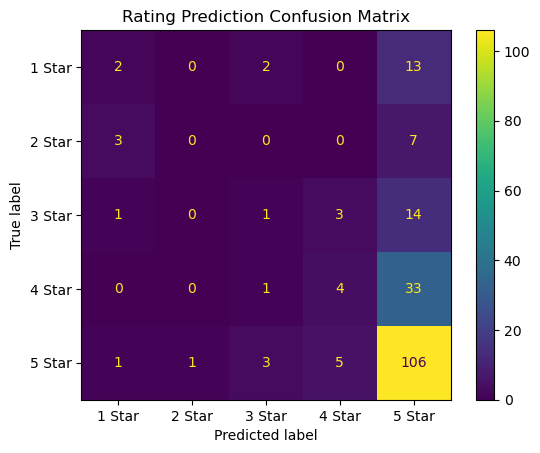

In [261]:
#Confusion Matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Display the confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix ,
    display_labels=[
        f"{i + 1} Star"
        for i in range(num_classes)
    ]
).plot()

plt.title("Rating Prediction Confusion Matrix")
plt.show()

#### Reflection on the model performance

**The Classification Report**

The neural network performs unevenly across the five rating classes. 

The test accuracy is at **56.5%** and a test loss of 1.50  This means that the model correctly predicts more than half of the reviews. 

The classification report reveals a major class imbalance problem. Class 5 contains 116 of the 200 test reviews (58%), while Class 2 contains only 10. The model seems more inclined to predict Class 5, with precision of 0.67, recall of 0.75, and F1-score of 0.71. This means it correctly identifies about 75% of the actual Class 5 reviews. 

Class 1 has moderate performance with an F1-score of 0.44, while Classes 3 and 4 are much more difficult for the model, with F1-scores of 0.11 and 0.24, respectively. Most notably, Class 2 has precision, recall, and F1-score of 0, meaning the neural network failed to correctly identify any Class 2 reviews.

The macro-average F1-score of 0.30 shows that the model does not perform well across all five classes, despite achieving 53% accuracy. The weighted F1-score of 0.50 is higher because the model performs relatively well on the much larger Class 5 group.


**The confusion matrix**

The confusion matrix shows that the neural network correctly classified 106 of 116 5-star reviews, but only 2 of 17 1-star reviews, none of the 10 2-star reviews, 1 of 19 3-star reviews, and 4 of 38 4-star reviews. 

Most of the incorrectly classified reviews were predicted as 5 stars, indicating that the model is strongly biased toward the majority class. 

The confusion matrix shows that it does not yet perform well across all rating classes.

**Hyperparameter Choices and Improvement Strategies**
I had initially set the the TF-IDF max_features at 1,000 and the Test Loss was 4. I later changed it to 5,000 to allow the model to use a larger vocabulary and capture more information from the reviews. This improved test accuracy from 52.5% to 56.5% and substantially reduced test loss from 4.00 to 1.50, suggesting that the richer text representation helped the model make better probability estimates. 

However, increasing the number of features alone did not solve the main problem of class imbalance. The model became particularly good at recognizing the dominant 5-star class, correctly identifying 106 of 116 5-star reviews, while performing poorly on the less common classes, especially 2-star reviews, where none were correctly classified.

Additionally, the number and size of hidden layers, dropout rate, learning rate, batch size, and number of epochs can also affect performance. More neurons or additional hidden layers may allow the network to learn more complex relationships between words and ratings. Increasing the number of epochs could also allow the model to learn more, except such an adjustments should ensure that training does not take too long, as long learning leads the model to memorize the training data instead of generalizing to unseen reviews.

To improve the model further, the priority should be addressing the class imbalance rather than simply increasing model complexity. Class weights can give greater importance to errors made on the underrepresented 1–4 star classes. 

TF-IDF can also be improved by including bigrams, allowing phrases such as "not good" or "very disappointed" to be represented rather than relying only on individual words. 

Early stopping can be introduced to stop training when validation performance no longer improves, while the learning rate, dropout rate, batch size, hidden-layer sizes, and TF-IDF vocabulary size can be systematically tuned and compared.